# Telecom Customer Analytics Project
## Step 1: Import Libraries and Load Dataset

In [1]:
import pandas as pd
field_Description = pd.read_excel(r"C:\Users\USER\OneDrive\Desktop\telecome project\Field Descriptions.xlsx")
telecom_data = pd.read_excel(r"C:\Users\USER\OneDrive\Desktop\telecome project\telcom_data (2).xlsx")
# to get the top 5 rows of the dataset
field_Description.head()
telecom_data.head()



,Bearer Id,Start,Start ms,End,End ms,Dur. (ms),IMSI,MSISDN/Number,IMEI,Last Location Name,...,Youtube DL (Bytes),Youtube UL (Bytes),Netflix DL (Bytes),Netflix UL (Bytes),Gaming DL (Bytes),Gaming UL (Bytes),Other DL (Bytes),Other UL (Bytes),Total UL (Bytes),Total DL (Bytes)
0,13114483460844900352,2019-04-04 12:01:18,770.0,2019-04-25 14:35:31,662.0,1823652.0,2.082014e+14,3.366496e+10,3.552121e+13,9164566995485190,...,15854611.0,2501332.0,8198936.0,9656251.0,278082303.0,14344150.0,171744450.0,8814393.0,36749741.0,308879636.0
1,13114483482878900224,2019-04-09 13:04:04,235.0,2019-04-25 08:15:48,606.0,1365104.0,2.082019e+14,3.368185e+10,3.579401e+13,L77566A,...,20247395.0,19111729.0,18338413.0,17227132.0,608750074.0,1170709.0,526904238.0,15055145.0,53800391.0,653384965.0
2,13114483484080500736,2019-04-09 17:42:11,1.0,2019-04-25 11:58:13,652.0,1361762.0,2.082003e+14,3.376063e+10,3.528151e+13,D42335A,...,19725661.0,14699576.0,17587794.0,6163408.0,229584621.0,395630.0,410692588.0,4215763.0,27883638.0,279807335.0
3,13114483485442799616,2019-04-10 00:31:25,486.0,2019-04-25 07:36:35,171.0,1321509.0,2.082014e+14,3.375034e+10,3.535661e+13,T21824A,...,21388122.0,15146643.0,13994646.0,1097942.0,799538153.0,10849722.0,749039933.0,12797283.0,43324218.0,846028530.0
4,13114483499480700928,2019-04-12 20:10:23,565.0,2019-04-25 10:40:32,954.0,1089009.0,2.082014e+14,3.369980e+10,3.540701e+13,D88865A,...,15259380.0,18962873.0,17124581.0,415218.0,527707248.0,3529801.0,550709500.0,13910322.0,38542814.0,569138589.0


## Step 2: Understanding the Dataset


In [2]:
telecom_data.shape
telecom_data.info()
telecom_data.isnull().sum().sort_values(ascending=False)



<class 'pandas.DataFrame'>
RangeIndex: 150001 entries, 0 to 150000
Data columns (total 55 columns):
 #   Column                                    Non-Null Count   Dtype         
---  ------                                    --------------   -----         
 0   Bearer Id                                 150001 non-null  object        
 1   Start                                     150000 non-null  datetime64[us]
 2   Start ms                                  150000 non-null  float64       
 3   End                                       150000 non-null  datetime64[us]
 4   End ms                                    150000 non-null  float64       
 5   Dur. (ms)                                 150000 non-null  float64       
 6   IMSI                                      149431 non-null  float64       
 7   MSISDN/Number                             148935 non-null  float64       
 8   IMEI                                      149429 non-null  float64       
 9   Last Location Name        

Nb of sec with 37500B < Vol UL              130254
Nb of sec with 6250B < Vol UL < 37500B      111843
Nb of sec with 125000B < Vol DL              97538
TCP UL Retrans. Vol (Bytes)                  96649
Nb of sec with 31250B < Vol DL < 125000B     93586
Nb of sec with 1250B < Vol UL < 6250B        92894
Nb of sec with 6250B < Vol DL < 31250B       88317
TCP DL Retrans. Vol (Bytes)                  88146
HTTP UL (Bytes)                              81810
HTTP DL (Bytes)                              81474
Avg RTT DL (ms)                              27829
Avg RTT UL (ms)                              27812
Last Location Name                            1153
MSISDN/Number                                 1066
Nb of sec with Vol UL < 1250B                  793
UL TP < 10 Kbps (%)                            792
10 Kbps < UL TP < 50 Kbps (%)                  792
UL TP > 300 Kbps (%)                           792
50 Kbps < UL TP < 300 Kbps (%)                 792
Nb of sec with Vol DL < 6250B  

## Step 3: Data Cleaning


In [3]:
# checking the duplicates 
telecom_data.duplicated().sum()

np.int64(0)

### Interpretation

There are no duplicate records in the telecom dataset. Therefore, no duplicate rows need to be removed before further analysis.


### 3.1 Check Data Types

In [4]:
telecom_data.dtypes

Bearer Id                                           object
Start                                       datetime64[us]
Start ms                                           float64
End                                         datetime64[us]
End ms                                             float64
Dur. (ms)                                          float64
IMSI                                               float64
MSISDN/Number                                      float64
IMEI                                               float64
Last Location Name                                  object
Avg RTT DL (ms)                                    float64
Avg RTT UL (ms)                                    float64
Avg Bearer TP DL (kbps)                            float64
Avg Bearer TP UL (kbps)                            float64
TCP DL Retrans. Vol (Bytes)                        float64
TCP UL Retrans. Vol (Bytes)                        float64
DL TP < 50 Kbps (%)                                float

### Interpretation

The dataset contains three main data types:
- **float64**: Numerical variables such as download, upload, duration, and throughput.
- **object/string**: Categorical variables such as handset manufacturer and handset type.
- **datetime**: Date and time variables such as Start and End.

Understanding the data types helps us apply the appropriate data cleaning techniques to each type of column.

### 3.2 Create a Backup Copy of the Dataset

In [5]:
telecom_clean = telecom_data.copy()


A copy of the original dataset is created before cleaning so that the original data remains unchanged. This allows us to return to the raw dataset if needed.

### 3.3 Identifying the numerical columns


In [6]:
# Identifying the numerical columns

numeric_columns = telecom_clean.select_dtypes(include=['float64', 'int64']).columns

numeric_columns

Index(['Start ms', 'End ms', 'Dur. (ms)', 'IMSI', 'MSISDN/Number', 'IMEI',
       'Avg RTT DL (ms)', 'Avg RTT UL (ms)', 'Avg Bearer TP DL (kbps)',
       'Avg Bearer TP UL (kbps)', 'TCP DL Retrans. Vol (Bytes)',
       'TCP UL Retrans. Vol (Bytes)', 'DL TP < 50 Kbps (%)',
       '50 Kbps < DL TP < 250 Kbps (%)', '250 Kbps < DL TP < 1 Mbps (%)',
       'DL TP > 1 Mbps (%)', 'UL TP < 10 Kbps (%)',
       '10 Kbps < UL TP < 50 Kbps (%)', '50 Kbps < UL TP < 300 Kbps (%)',
       'UL TP > 300 Kbps (%)', 'HTTP DL (Bytes)', 'HTTP UL (Bytes)',
       'Activity Duration DL (ms)', 'Activity Duration UL (ms)', 'Dur. (ms).1',
       'Nb of sec with 125000B < Vol DL',
       'Nb of sec with 1250B < Vol UL < 6250B',
       'Nb of sec with 31250B < Vol DL < 125000B',
       'Nb of sec with 37500B < Vol UL',
       'Nb of sec with 6250B < Vol DL < 31250B',
       'Nb of sec with 6250B < Vol UL < 37500B',
       'Nb of sec with Vol DL < 6250B', 'Nb of sec with Vol UL < 1250B',
       'Social Media DL (

### Interpretation

The numeric columns in the dataset have been identified successfully. These columns will be used to replace missing values with the mean, ensuring that only numerical features are modified while text and datetime columns remain unchanged.

###  3.4 Replace Missing Values with Mean

In [7]:
# Replace Missing Values with Mean
telecom_clean[numeric_columns] = telecom_clean[numeric_columns].fillna(
    telecom_clean[numeric_columns].mean() 
)



### Verify that the missing values were filled 

In [8]:
telecom_clean.isnull().sum().sort_values(ascending=False)


Last Location Name                          1153
Handset Type                                 572
Handset Manufacturer                         572
End                                            1
Start                                          1
Start ms                                       0
End ms                                         0
IMSI                                           0
MSISDN/Number                                  0
IMEI                                           0
Avg RTT DL (ms)                                0
Avg RTT UL (ms)                                0
Avg Bearer TP DL (kbps)                        0
Avg Bearer TP UL (kbps)                        0
TCP DL Retrans. Vol (Bytes)                    0
TCP UL Retrans. Vol (Bytes)                    0
DL TP < 50 Kbps (%)                            0
50 Kbps < DL TP < 250 Kbps (%)                 0
250 Kbps < DL TP < 1 Mbps (%)                  0
DL TP > 1 Mbps (%)                             0
UL TP < 10 Kbps (%) 

### Interpretation

The missing values in all numerical columns have been successfully replaced using the mean of their respective columns.

The remaining missing values belong to categorical (text) columns and datetime columns. These require different treatment because replacing text or dates with a numerical mean is not appropriate.

### Step 3.6: Replace Missing Values in Categorical Columns with Mode

In [9]:
categorical_columns = telecom_clean.select_dtypes(include=['object']).columns

categorical_columns

C:\Users\USER\AppData\Local\Temp\ipykernel_2820\3175511889.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = telecom_clean.select_dtypes(include=['object']).columns


Index(['Bearer Id', 'Last Location Name', 'Handset Manufacturer',
       'Handset Type'],
      dtype='str')

### Fill Missing Values with Mode

In [10]:
for column in categorical_columns:
    telecom_clean[column] = telecom_clean[column].fillna(
        telecom_clean[column].mode()[0]
    )

telecom_clean.isnull().sum().sort_values(ascending=False)

Start                                       1
End                                         1
Bearer Id                                   0
Start ms                                    0
End ms                                      0
Dur. (ms)                                   0
IMSI                                        0
MSISDN/Number                               0
IMEI                                        0
Last Location Name                          0
Avg RTT DL (ms)                             0
Avg RTT UL (ms)                             0
Avg Bearer TP DL (kbps)                     0
Avg Bearer TP UL (kbps)                     0
TCP DL Retrans. Vol (Bytes)                 0
TCP UL Retrans. Vol (Bytes)                 0
DL TP < 50 Kbps (%)                         0
50 Kbps < DL TP < 250 Kbps (%)              0
250 Kbps < DL TP < 1 Mbps (%)               0
DL TP > 1 Mbps (%)                          0
UL TP < 10 Kbps (%)                         0
10 Kbps < UL TP < 50 Kbps (%)     

### 3.7 Handle Missing Datetime Values

In [11]:
telecom_clean.dropna(subset=['Start', 'End'], inplace=True)
telecom_clean.isnull().sum().sort_values(ascending=False)


Bearer Id                                   0
Start                                       0
Start ms                                    0
End                                         0
End ms                                      0
Dur. (ms)                                   0
IMSI                                        0
MSISDN/Number                               0
IMEI                                        0
Last Location Name                          0
Avg RTT DL (ms)                             0
Avg RTT UL (ms)                             0
Avg Bearer TP DL (kbps)                     0
Avg Bearer TP UL (kbps)                     0
TCP DL Retrans. Vol (Bytes)                 0
TCP UL Retrans. Vol (Bytes)                 0
DL TP < 50 Kbps (%)                         0
50 Kbps < DL TP < 250 Kbps (%)              0
250 Kbps < DL TP < 1 Mbps (%)               0
DL TP > 1 Mbps (%)                          0
UL TP < 10 Kbps (%)                         0
10 Kbps < UL TP < 50 Kbps (%)     

### Data Cleaning Summary

The telecom dataset was cleaned using the following steps:

- Checked for duplicate records (no duplicates found).
- Identified data types of all columns.
- Created a backup copy of the original dataset.
- Replaced missing values in numerical columns using the mean.
- Replaced missing values in categorical columns using the mode.
- Removed rows containing missing datetime values.
- Verified that no missing values remained after cleaning.

The dataset is now clean and ready for Exploratory Data Analysis (EDA).

## 4: Exploratory Data Analysis (EDA)

### 4.1 Summary Statistics

In [12]:
telecom_clean.describe()

,Start,Start ms,End,End ms,Dur. (ms),IMSI,MSISDN/Number,IMEI,Avg RTT DL (ms),Avg RTT UL (ms),...,Youtube DL (Bytes),Youtube UL (Bytes),Netflix DL (Bytes),Netflix UL (Bytes),Gaming DL (Bytes),Gaming UL (Bytes),Other DL (Bytes),Other UL (Bytes),Total UL (Bytes),Total DL (Bytes)
count,150000,150000.000000,150000,150000.000000,1.500000e+05,1.500000e+05,1.500000e+05,1.500000e+05,150000.000000,150000.000000,...,1.500000e+05,1.500000e+05,1.500000e+05,1.500000e+05,1.500000e+05,1.500000e+05,1.500000e+05,1.500000e+05,1.500000e+05,1.500000e+05
mean,2019-04-26 12:36:38.953740,499.188200,2019-04-27 17:40:08.059673,498.800880,1.046086e+05,2.082016e+14,4.188282e+10,4.847455e+13,109.795706,17.662883,...,1.163407e+07,1.100941e+07,1.162685e+07,1.100175e+07,4.220447e+08,8.288398e+06,4.211005e+08,8.264799e+06,4.112121e+07,4.546434e+08
min,2019-04-04 12:01:18,0.000000,2019-04-24 22:59:58,0.000000,7.142000e+03,2.040471e+14,3.360100e+10,4.400152e+11,0.000000,0.000000,...,5.300000e+01,1.050000e+02,4.200000e+01,3.500000e+01,2.516000e+03,5.900000e+01,3.290000e+03,1.480000e+02,2.866892e+06,7.114041e+06
25%,2019-04-25 00:26:00.750000,250.000000,2019-04-26 07:30:11.500000,251.000000,5.744050e+04,2.082014e+14,3.365151e+10,3.546261e+13,35.000000,3.000000,...,5.833482e+06,5.517962e+06,5.777095e+06,5.475977e+06,2.104706e+08,4.128424e+06,2.101824e+08,4.145904e+06,3.322201e+07,2.431068e+08
50%,2019-04-26 08:51:24.500000,499.000000,2019-04-27 23:02:05,500.000000,8.639900e+04,2.082015e+14,3.366380e+10,3.572241e+13,54.000000,7.000000,...,1.161601e+07,1.101348e+07,1.164222e+07,1.099631e+07,4.234082e+08,8.291215e+06,4.218057e+08,8.267086e+06,4.114331e+07,4.558411e+08
75%,2019-04-27 18:18:59.750000,749.000000,2019-04-29 07:15:07.500000,750.000000,1.324302e+05,2.082018e+14,3.368473e+10,8.611970e+13,109.795706,17.662883,...,1.744855e+07,1.651559e+07,1.747050e+07,1.650729e+07,6.331747e+08,1.243163e+07,6.316950e+08,1.238420e+07,4.903424e+07,6.657055e+08
max,2019-04-29 07:28:43,999.000000,2019-04-30 23:59:27,999.000000,1.859336e+06,2.140743e+14,8.823971e+14,9.900120e+13,96923.000000,7120.000000,...,2.325910e+07,2.201196e+07,2.325919e+07,2.201196e+07,8.434419e+08,1.655879e+07,8.434425e+08,1.655882e+07,7.833131e+07,9.029696e+08
std,NaN,288.611834,NaN,288.097653,8.103762e+04,2.144730e+10,2.438739e+12,2.237367e+13,559.344484,76.530188,...,6.710591e+06,6.345445e+06,6.725240e+06,6.359511e+06,2.439683e+08,4.782716e+06,2.432058e+08,4.769020e+06,1.127639e+07,2.441429e+08


### Interpretation

The summary statistics provide an overview of the numerical variables in the telecom dataset.

- The dataset contains **150,000 cleaned observations**.
- The mean values represent the average customer usage for each numerical variable.
- The standard deviation indicates considerable variability in customer behavior.
- The minimum and maximum values show that some variables contain extremely large values, suggesting possible outliers.
- The quartiles (25%, 50%, and 75%) describe the distribution of the data and provide insight into the spread of customer usage.
- Overall, the dataset is ready for visualization and deeper exploratory analysis.

## 4.2 Distribution of Session Duration

A histogram is used to visualize the distribution of session duration. It helps us understand how frequently different session durations occur and whether the data is normally distributed or skewed.

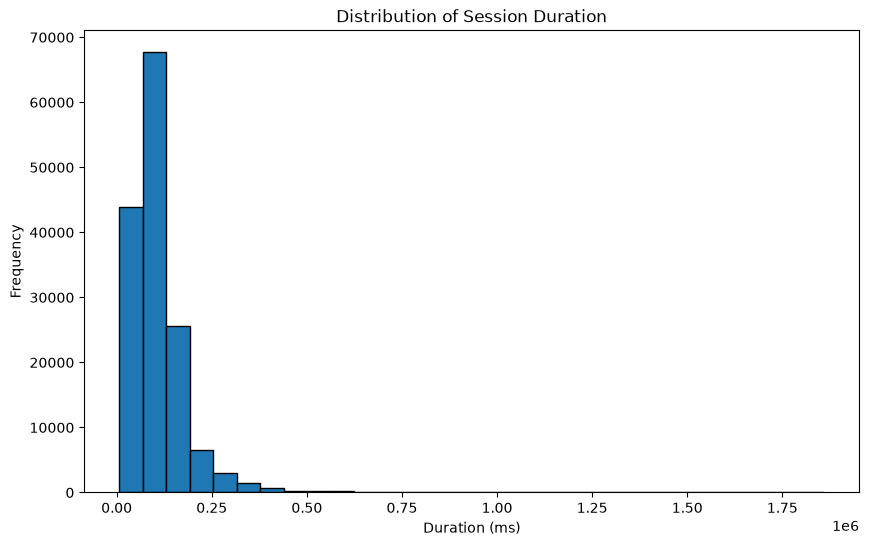

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.hist(telecom_clean['Dur. (ms)'], bins=30, edgecolor='black')

plt.title('Distribution of Session Duration')
plt.xlabel('Duration (ms)')
plt.ylabel('Frequency')

plt.show()

### Interpretation

The histogram shows the distribution of customer session duration.

- Most telecom sessions are concentrated within shorter durations.
- The distribution is positively (right) skewed, indicating that a small number of customers have significantly longer session durations.
- A few extreme values are visible, suggesting the presence of heavy users or outliers.
- The data is not normally distributed, which is common in telecom usage datasets.


## 4.3 Box Plot of Session Duration

A box plot is used to identify the spread of the data and detect potential outliers. It summarizes the distribution using the median, quartiles, and extreme values.

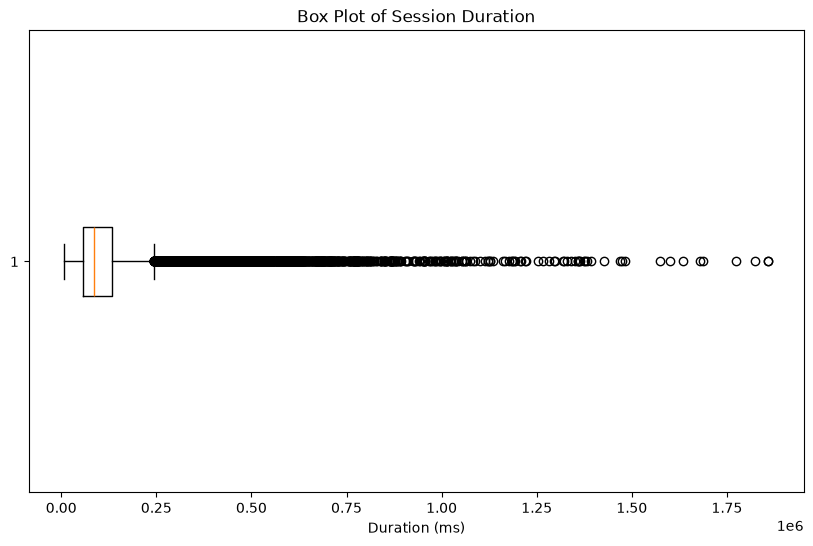

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.boxplot(telecom_clean['Dur. (ms)'], orientation='horizontal') 

plt.title('Box Plot of Session Duration')
plt.xlabel('Duration (ms)')

plt.show()

### Interpretation

The box plot indicates that session duration contains a large number of outliers. Most customer sessions are concentrated within a relatively small range, while a few sessions have exceptionally long durations. This suggests that the distribution is positively skewed and that some users spend significantly more time on the network than the average customer. 

### 4.4: Histogram of Total Download (Bytes)

### Why are we plotting this?

A histogram of Total Download (Bytes) helps us understand how internet download usage is distributed among customers. It shows whether most customers download similar amounts of data or whether a few customers consume significantly higher amounts.

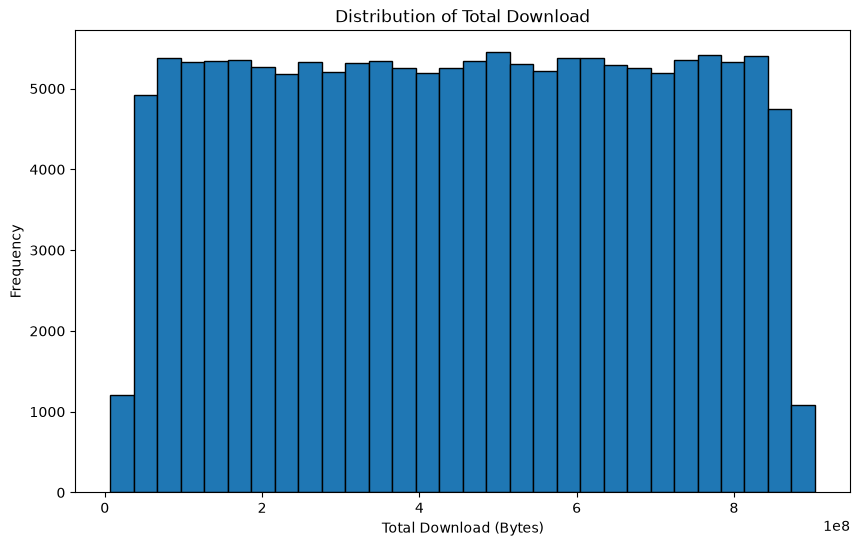

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.hist(telecom_clean['Total DL (Bytes)'],
         bins=30,
         edgecolor='black')

plt.title("Distribution of Total Download")
plt.xlabel("Total Download (Bytes)")
plt.ylabel("Frequency")

plt.show()

### Interpretation

The histogram shows that Total Download (Bytes) is fairly evenly distributed across the dataset. Unlike session duration, download usage does not exhibit a strong positive skew. Customers are spread across different download usage levels, indicating a wide variety of internet consumption patterns.

## 4.5 Box Plot of Total Download


A box plot summarizes the distribution of Total Download (Bytes) and helps identify potential outliers among customers with unusually high or low download usage.

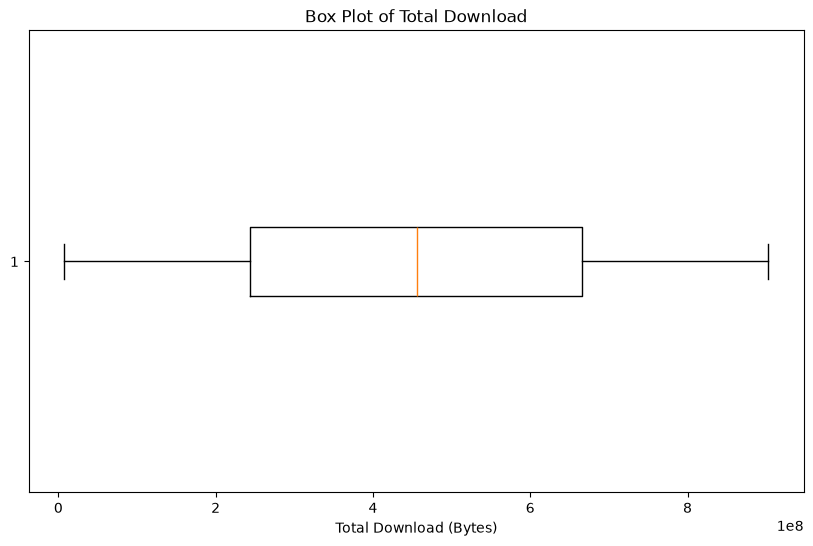

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.boxplot(
    telecom_clean['Total DL (Bytes)'],
    orientation='horizontal'
)

plt.title("Box Plot of Total Download")
plt.xlabel("Total Download (Bytes)")

plt.show()

### Interpretation

The box plot shows that Total Download (Bytes) is fairly evenly distributed with no significant outliers. The median is positioned near the center of the box, indicating a balanced distribution. The spread of the data suggests that customers have a wide range of download usage, but there are no unusually extreme download values.

### 4.4 Correlation Heatmap 


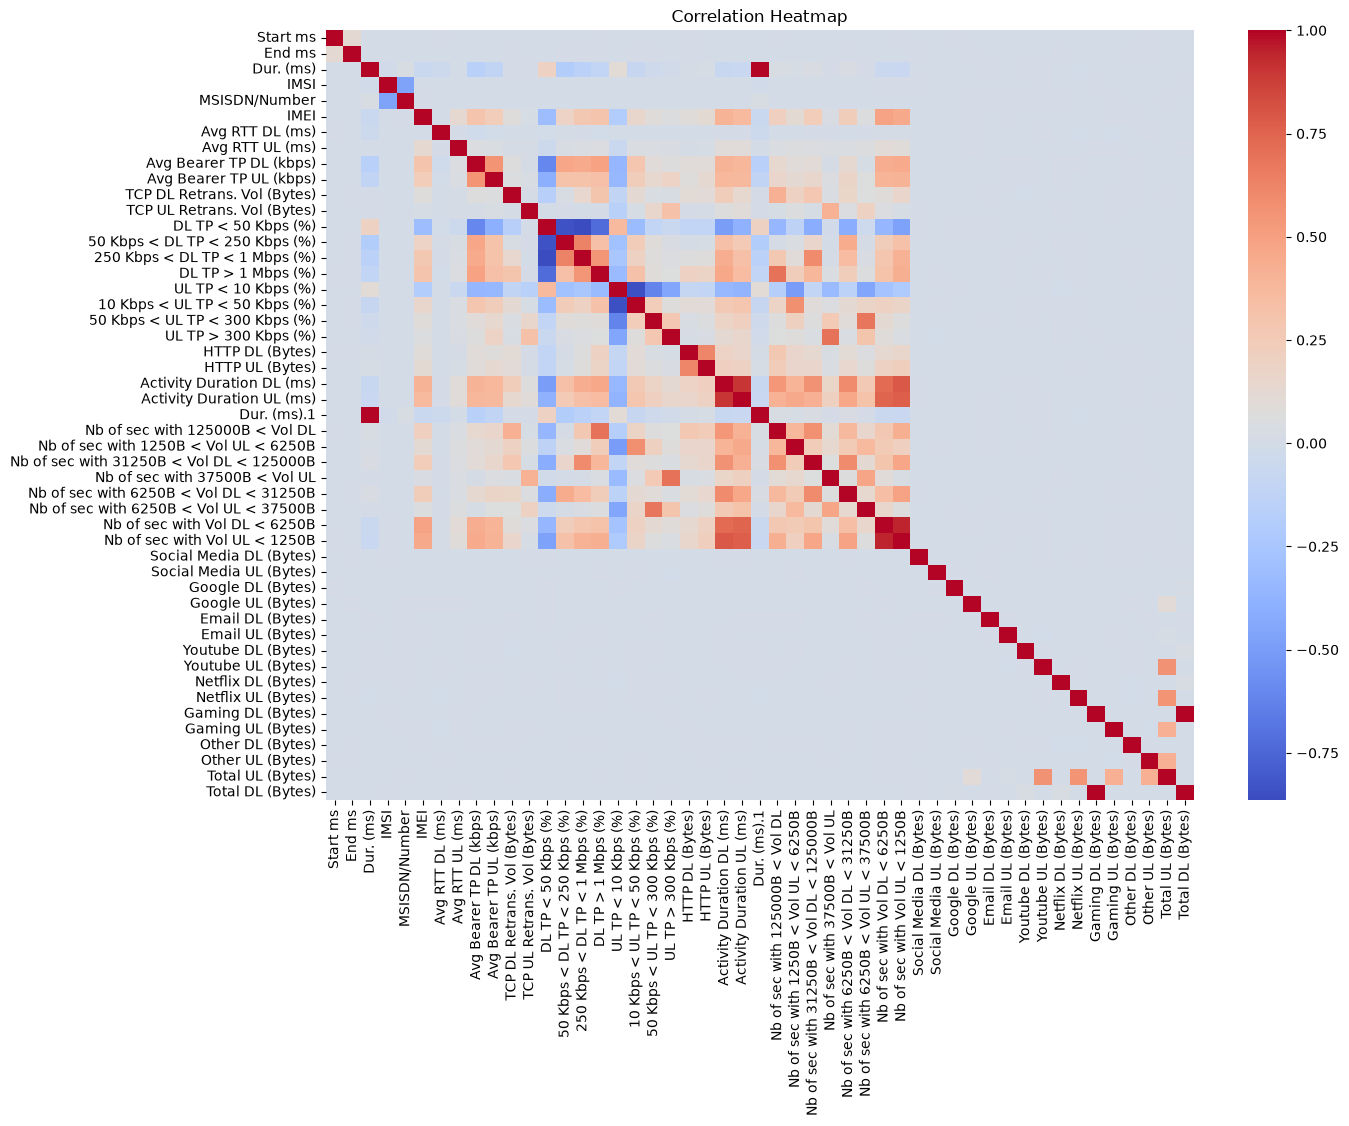

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14,10))

sns.heatmap(
    telecom_clean.select_dtypes(include=['float64','int64']).corr(),
    cmap='coolwarm',
    annot=False
)

plt.title("Correlation Heatmap")
plt.show()

### Interpretation

- The heatmap displays the correlation between all numerical variables.
- Dark red colors indicate a strong positive correlation.
- Dark blue colors indicate a strong negative correlation.
- Light colors indicate little or no correlation.
- Most variables show weak to moderate correlations, while a few download and upload-related variables have stronger positive relationships.
- The heatmap helps identify important features for further analysis and predictive modeling.

## 4.5 Scatter Plot: Total Download vs Total Upload

A scatter plot is used to visualize the relationship between two numerical variables. It helps identify positive or negative correlations, clusters, and unusual observations.

Here, we compare Total Download (Bytes) with Total Upload (Bytes) to understand whether customers with higher download usage also tend to have higher upload usage.

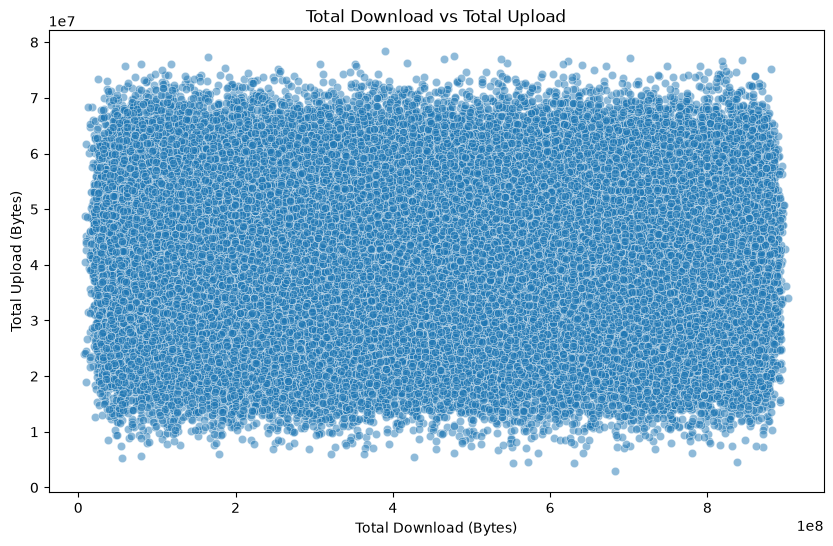

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.scatterplot(
    x=telecom_clean['Total DL (Bytes)'],
    y=telecom_clean['Total UL (Bytes)'],
    alpha=0.5
)

plt.title("Total Download vs Total Upload")
plt.xlabel("Total Download (Bytes)")
plt.ylabel("Total Upload (Bytes)")

plt.show()

### Interpretation:

The scatter plot compares Total Download (Bytes) and Total Upload (Bytes).
The data points are widely scattered across the graph.
There is no clear linear relationship between download and upload traffic.
This suggests that customers with higher download usage do not necessarily have higher upload usage.
Further statistical analysis (such as the correlation coefficient) would be needed to measure the strength of the relationship.

## Top 10 Handset Manufacturers

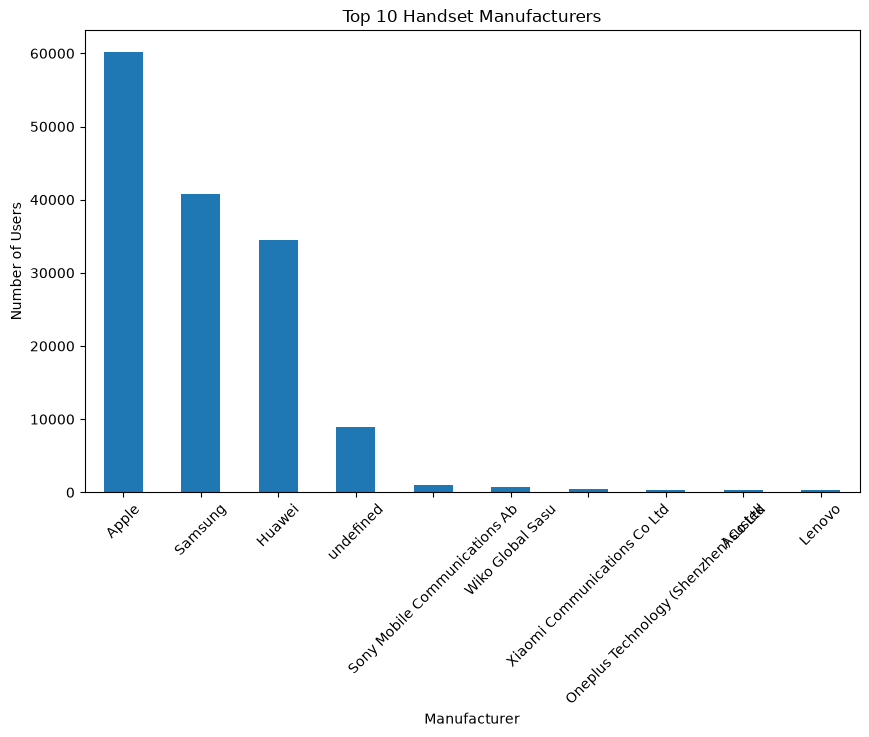

In [19]:
import matplotlib.pyplot as plt

top_manufacturers = telecom_clean['Handset Manufacturer'].value_counts().head(10)

plt.figure(figsize=(10,6))
top_manufacturers.plot(kind='bar')

plt.title("Top 10 Handset Manufacturers")
plt.xlabel("Manufacturer")
plt.ylabel("Number of Users")
plt.xticks(rotation=45)

plt.show()

### Interpretation:

Apple is the most commonly used handset manufacturer, with approximately 60,000 users.
Samsung is the second most popular manufacturer, followed by Huawei.
A significant number of records are labeled as 'undefined', which may indicate missing or unidentified manufacturer information.
Other manufacturers such as Sony, Xiaomi, OnePlus, Lenovo, and Wiko have comparatively fewer users.
This indicates that the telecom company's customer base is largely dominated by Apple, Samsung, and Huawei devices.

## Top 10 Handset Types

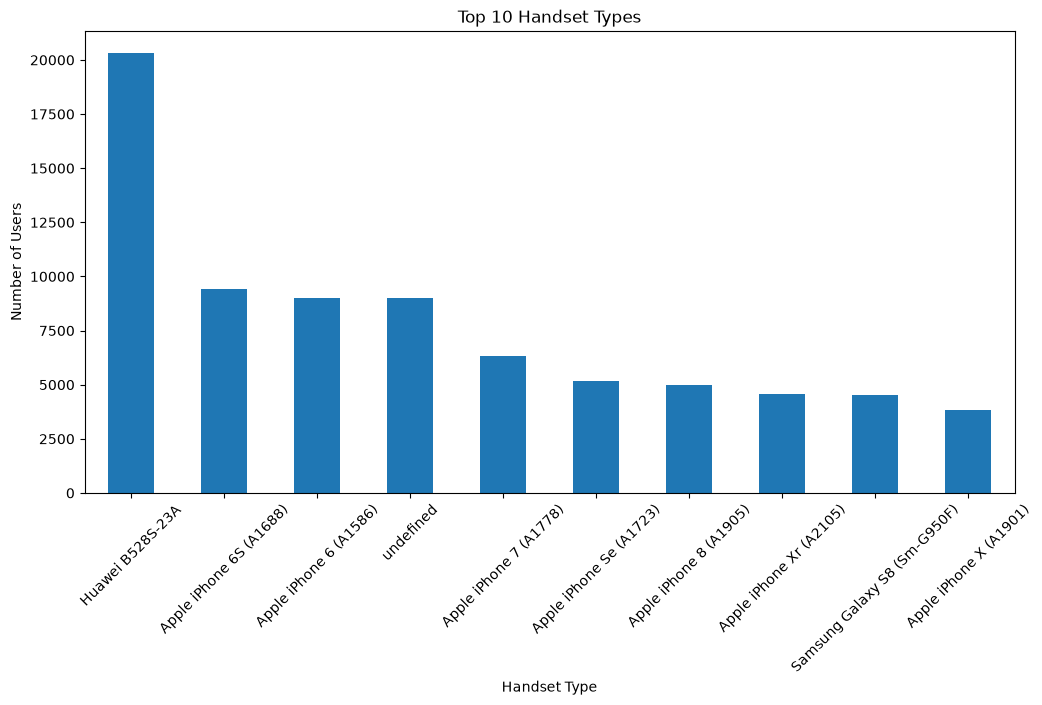

In [20]:
top_handsets = telecom_clean['Handset Type'].value_counts().head(10)

plt.figure(figsize=(12,6))
top_handsets.plot(kind='bar')

plt.title("Top 10 Handset Types")
plt.xlabel("Handset Type")
plt.ylabel("Number of Users")
plt.xticks(rotation=45)

plt.show()

### Interpretation:

The graph displays the ten most frequently used handset models. A small number of handset models account for a large proportion of users, indicating that customer preferences are concentrated on a limited set of devices. This information can help the telecom company prioritize device-specific optimization, customer support, and marketing efforts.

The Huawei B528S-23A is the most widely used handset type, followed by several Apple iPhone models such as the iPhone 6S, iPhone 6, iPhone 7, iPhone SE, iPhone 8, and iPhone X. The presence of 'undefined' records indicates missing handset information that should be investigated to improve data quality. Overall, the telecom company can use these insights to optimize network compatibility, improve customer support, and design targeted marketing campaigns for the most popular devices.

# 5. Application Usage Analysis

This section analyzes the total network traffic generated by different applications such as Social Media, Google, Email, YouTube, Netflix, Gaming, and Other services. The objective is to identify which applications consume the highest amount of network resources.

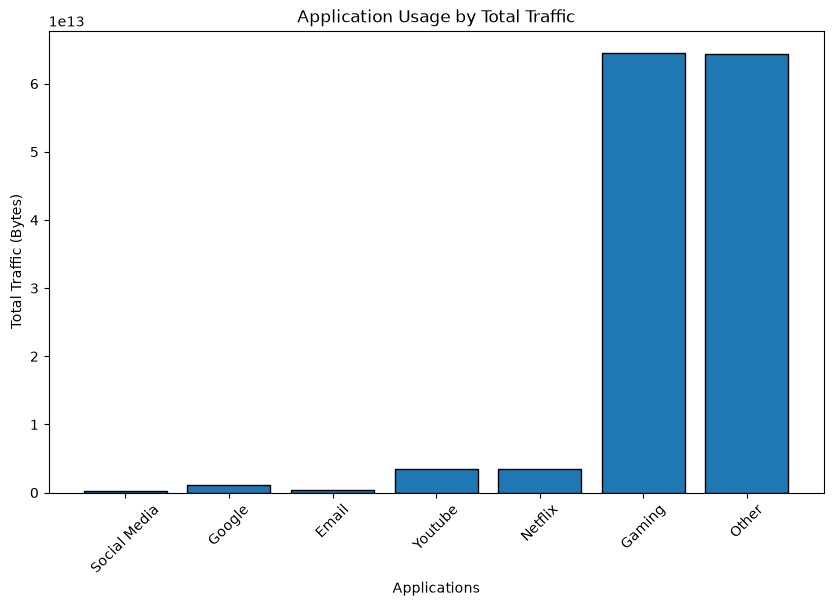

In [21]:
applications = {
    'Social Media': telecom_clean['Social Media DL (Bytes)'].sum() + telecom_clean['Social Media UL (Bytes)'].sum(),
    'Google': telecom_clean['Google DL (Bytes)'].sum() + telecom_clean['Google UL (Bytes)'].sum(),
    'Email': telecom_clean['Email DL (Bytes)'].sum() + telecom_clean['Email UL (Bytes)'].sum(),
    'Youtube': telecom_clean['Youtube DL (Bytes)'].sum() + telecom_clean['Youtube UL (Bytes)'].sum(),
    'Netflix': telecom_clean['Netflix DL (Bytes)'].sum() + telecom_clean['Netflix UL (Bytes)'].sum(),
    'Gaming': telecom_clean['Gaming DL (Bytes)'].sum() + telecom_clean['Gaming UL (Bytes)'].sum(),
    'Other': telecom_clean['Other DL (Bytes)'].sum() + telecom_clean['Other UL (Bytes)'].sum()
}

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.bar(
    applications.keys(),
    applications.values(),
    edgecolor='black'
)

plt.title("Application Usage by Total Traffic")
plt.xlabel("Applications")
plt.ylabel("Total Traffic (Bytes)")
plt.xticks(rotation=45)

plt.show()

### Interpretation:
The chart shows the total network traffic generated by different applications. Gaming and Other applications generate the highest traffic by a significant margin, followed by YouTube and Netflix. Google, Social Media, and Email contribute comparatively less network traffic. This indicates that entertainment and miscellaneous applications consume the majority of the telecom network bandwidth.

Business Insight:
The telecom company should prioritize network resources for Gaming and Other applications, as they account for the largest share of traffic. Understanding application usage patterns helps optimize bandwidth allocation, improve network performance, and enhance customer experience during peak usage periods.

Business Recommendation:
Increase network capacity for high-traffic applications such as Gaming and Other services. Monitor usage trends regularly and optimize network infrastructure to reduce congestion and improve service quality. Partnering with major content providers can further enhance network efficiency.

# 6. Executive Summary

This Telecom Customer Analytics Project analyzed customer network usage, handset information, and application traffic using Python. The dataset was cleaned by handling missing values and preparing numerical and categorical variables for analysis.

Exploratory Data Analysis (EDA) was performed using histograms, boxplots, correlation heatmaps, scatter plots, and bar charts to identify customer behavior and usage patterns.

The analysis provides insights into handset popularity, application traffic distribution, and network usage trends that can help improve business decision-making and network optimization.

# 7. Key Findings

• The dataset contained missing values that were successfully handled using mean and mode imputation.

• Most numerical variables showed skewed distributions with several outliers.

• The correlation heatmap indicated only a few strong relationships between network-related variables.

• There is no strong relationship between Total Download and Total Upload traffic.

• Apple, Samsung, and Huawei are the most widely used handset manufacturers.

• Huawei B528S-23A is the most commonly used handset model.

• Gaming and Other applications generate the highest amount of network traffic.

• These insights can help improve bandwidth allocation, customer service, and infrastructure planning.

# 8. Final Business Recommendations

• Increase network capacity for high-traffic applications such as Gaming and Other.

• Focus customer support and software optimization on the most commonly used handset manufacturers and models.

• Continuously monitor application traffic trends to improve Quality of Service (QoS).

• Optimize network resources during peak traffic hours to reduce congestion.

• Improve data collection processes to minimize missing or undefined handset information.

• Use customer usage patterns for future marketing campaigns and service planning.

# 9. Conclusion

The Telecom Customer Analytics Project successfully explored customer usage behavior, device popularity, and application traffic using Python.

The project demonstrates the complete data analysis workflow, including data cleaning, exploratory data analysis, visualization, and business insights.

The findings can support telecom companies in making data-driven decisions related to network optimization, customer experience, and strategic planning.